<a href="https://colab.research.google.com/github/Sarah-Basil/BTT_ML_Final_Project/blob/main/Student_Performance_Prediction_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Course : CS 513- Data Analytics & Machine Learning
# First Name : Sarah
# Last Name : Basil
# Id : 20024882
# purpose : Final Project on predicting student career

In [1]:
# necessary imports:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# 1. Initial Data Inspection:

In [3]:
# loading dataset:
df = pd.read_csv("student_career_information.csv")

df.head()

,CGPA,Did you do webdev during college time ?,Are you good at Data analysis ?,reading and writing skills,Are you a tech person ?,Were you in a non tech society ?,Are you good at coding ?,Have you developed mobile apps ?,Are you good at communication ?,Do you have specialization in security,Have you ever handled large databases ?,Do you have knowlege of statistics and data science?,Are you proficient in English ?,Have you ever managed some event?,Do you write technical blogs ?,Are you into marketing ?,Are you a ML expert ?,Do you have a lot of connections ?,Have you ever built live project ?,Role
0,8.0,NaN,no,excellent,no,no,yes,yes,no,no,no,no,yes,no,no,no,no,no,no,Developer
1,8.8,yes,no,poor,yes,no,NaN,no,no,no,no,yes,NaN,no,no,no,yes,no,no,ML engineer
2,7.9,no,no,poor,no,yes,no,no,yes,no,no,no,yes,yes,no,no,no,no,no,Management
3,8.0,yes,no,medium,yes,no,yes,yes,no,no,yes,no,no,no,no,no,no,no,yes,Developer
4,6.4,no,no,poor,no,yes,yes,no,yes,no,no,no,yes,no,no,no,no,yes,no,Marketing


In [4]:
# basic overview of the data:

print("Shape:", df.shape)
print()

print("Columns:")
print(df.columns.tolist())
print()

# data types & missing values:

print("Data types:")
print(df.dtypes)
print()

print("Missing values:")
print(df.isnull().sum())

print("Missing value percentages:")
print((df.isnull().mean() * 100).round(2))

Shape: (516, 20)

Columns:
['CGPA', 'Did you do webdev during college time ?', 'Are you good at Data analysis ?', 'reading and writing skills', 'Are you a tech person ?', 'Were you in a non tech society ?', 'Are you good at coding ?', 'Have you developed mobile apps ?', 'Are you good at communication ?', 'Do you have specialization in security', 'Have you ever handled large databases ?', 'Do you have knowlege of statistics and data science?', 'Are you proficient in English ?', 'Have you ever managed some event?', 'Do you write technical blogs ?', 'Are you into marketing ?', 'Are you a ML expert ?', 'Do you have a lot of connections ?', 'Have you ever built live project ?', 'Role']

Data types:
CGPA                                                    float64
Did you do webdev during college time ?                  object
Are you good at Data analysis ?                          object
reading and writing skills                               object
Are you a tech person ?                  

In [8]:
# info about duplicates
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate percentage:", round(df.duplicated().mean() * 100, 2), "%")

Duplicate rows: 171
Duplicate percentage: 33.14 %


In [9]:
# looking at unique values per column
for col in df.columns:
    print("\n" + "="*60)
    print(col)
    print("Unique count:", df[col].nunique(dropna=False))
    print(df[col].value_counts(dropna=False).head(20))

# checking summary stats:
df.describe()


CGPA
Unique count: 41
CGPA
8.3    31
9.1    28
6.5    24
6.3    22
9.2    21
7.4    20
8.5    20
8.0    20
7.0    19
7.8    17
8.2    16
7.2    16
8.6    15
8.9    15
7.9    14
6.9    14
8.1    14
6.4    13
6.7    13
8.7    13
Name: count, dtype: int64

Did you do webdev during college time ?
Unique count: 3
Did you do webdev during college time ?
no     273
yes    242
NaN      1
Name: count, dtype: int64

Are you good at Data analysis ?
Unique count: 3
Are you good at Data analysis ?
no     402
yes    112
NaN      2
Name: count, dtype: int64

reading and writing skills
Unique count: 4
reading and writing skills
excellent    181
poor         171
medium       162
NaN            2
Name: count, dtype: int64

Are you a tech person ?
Unique count: 2
Are you a tech person ?
no     262
yes    254
Name: count, dtype: int64

Were you in a non tech society ?
Unique count: 3
Were you in a non tech society ?
no     321
yes    191
NaN      4
Name: count, dtype: int64

Are you good at coding ?
Uniq

,CGPA
count,516.000000
mean,7.680039
std,1.311550
min,0.000000
25%,6.800000
50%,7.900000
75%,8.600000
max,9.900000


In [11]:
# possible target columns:
print("Columns with low number of unique values:")
for col in df.columns:
    unique_count = df[col].nunique(dropna=False)
    if unique_count <= 10:
        print(f"{col}: {unique_count} unique values")
        print(df[col].value_counts(dropna=False))
        print()

Columns with low number of unique values:
Did you do webdev during college time ?: 3 unique values
Did you do webdev during college time ?
no     273
yes    242
NaN      1
Name: count, dtype: int64

Are you good at Data analysis ?: 3 unique values
Are you good at Data analysis ?
no     402
yes    112
NaN      2
Name: count, dtype: int64

reading and writing skills: 4 unique values
reading and writing skills
excellent    181
poor         171
medium       162
NaN            2
Name: count, dtype: int64

Are you a tech person ?: 2 unique values
Are you a tech person ?
no     262
yes    254
Name: count, dtype: int64

Were you in a non tech society ?: 3 unique values
Were you in a non tech society ?
no     321
yes    191
NaN      4
Name: count, dtype: int64

Are you good at coding ?: 3 unique values
Are you good at coding ?
yes    332
no     182
NaN      2
Name: count, dtype: int64

Have you developed mobile apps ?: 3 unique values
Have you developed mobile apps ?
no     359
yes    155
NaN  

# 2. Data Cleaning

In [12]:
# making a cleaned copy of the dataset
data = df.copy()

# renaming columns to simpler names
data = data.rename(columns={
    "CGPA": "cgpa",
    "Did you do webdev during college time ?": "webdev",
    "Are you good at Data analysis ?": "data_analysis",
    "reading and writing skills": "reading_writing",
    "Are you a tech person ?": "tech_person",
    "Were you in a non tech society ?": "non_tech_society",
    "Are you good at coding ?": "coding",
    "Have you developed mobile apps ?": "mobile_apps",
    "Are you good at communication ?": "communication",
    "Do you have specialization in security": "security_specialization",
    "Have you ever handled large databases ?": "large_databases",
    "Do you have knowlege of statistics and data science?": "stats_ds_knowledge",
    "Are you proficient in English ?": "english",
    "Have you ever managed some event?": "event_management",
    "Do you write technical blogs ?": "technical_blogs",
    "Are you into marketing ?": "marketing_interest",
    "Are you a ML expert ?": "ml_expert",
    "Do you have a lot of connections ?": "connections",
    "Have you ever built live project ?": "live_project",
    "Role": "role"
})

print(data.columns.tolist())
data.head()

['cgpa', 'webdev', 'data_analysis', 'reading_writing', 'tech_person', 'non_tech_society', 'coding', 'mobile_apps', 'communication', 'security_specialization', 'large_databases', 'stats_ds_knowledge', 'english', 'event_management', 'technical_blogs', 'marketing_interest', 'ml_expert', 'connections', 'live_project', 'role']


,cgpa,webdev,data_analysis,reading_writing,tech_person,non_tech_society,coding,mobile_apps,communication,security_specialization,large_databases,stats_ds_knowledge,english,event_management,technical_blogs,marketing_interest,ml_expert,connections,live_project,role
0,8.0,NaN,no,excellent,no,no,yes,yes,no,no,no,no,yes,no,no,no,no,no,no,Developer
1,8.8,yes,no,poor,yes,no,NaN,no,no,no,no,yes,NaN,no,no,no,yes,no,no,ML engineer
2,7.9,no,no,poor,no,yes,no,no,yes,no,no,no,yes,yes,no,no,no,no,no,Management
3,8.0,yes,no,medium,yes,no,yes,yes,no,no,yes,no,no,no,no,no,no,no,yes,Developer
4,6.4,no,no,poor,no,yes,yes,no,yes,no,no,no,yes,no,no,no,no,yes,no,Marketing


In [13]:
# inspecting other qualities of the data:

print("Shape before cleaning:", data.shape)
print("Exact duplicate rows:", data.duplicated().sum())

print("\nCGPA value counts for suspicious values:")
print(data["cgpa"].value_counts().sort_index().head(10))

print("\nRows where CGPA is 0:")
print(data[data["cgpa"] == 0])

print("\nRole distribution:")
print(data["role"].value_counts())

print("\nRole percentage:")
print((data["role"].value_counts(normalize=True) * 100).round(2))

Shape before cleaning: (516, 20)
Exact duplicate rows: 171

CGPA value counts for suspicious values:
cgpa
0.0     4
5.1     3
5.3     3
5.5     2
5.6    10
5.7     5
5.9    11
6.1     8
6.3    22
6.4    13
Name: count, dtype: int64

Rows where CGPA is 0:
     cgpa webdev data_analysis reading_writing tech_person non_tech_society  \
29    0.0     no            no       excellent          no               no   
214   0.0     no            no       excellent          no               no   
273   0.0     no            no          medium          no               no   
334   0.0     no            no       excellent          no               no   

    coding mobile_apps communication security_specialization large_databases  \
29      no         NaN           yes                      no              no   
214     no          no           yes                      no              no   
273     no          no           yes                      no              no   
334     no          no       

In [14]:
# creating cleaned dataset
cleaned_data = data.copy()

# removing duplicate rows
cleaned_data = cleaned_data.drop_duplicates()

# removing invalid CGPA rows
cleaned_data = cleaned_data[cleaned_data["cgpa"] > 0]

print("Shape after duplicate + CGPA cleaning:", cleaned_data.shape)
print()

print("Remaining missing values:")
print(cleaned_data.isnull().sum())
print()

print("Remaining duplicate rows:")
print(cleaned_data.duplicated().sum())
print()

print("Role distribution after cleaning:")
print(cleaned_data["role"].value_counts())

Shape after duplicate + CGPA cleaning: (342, 20)

Remaining missing values:
cgpa                       0
webdev                     1
data_analysis              2
reading_writing            1
tech_person                0
non_tech_society           4
coding                     2
mobile_apps                1
communication              4
security_specialization    3
large_databases            3
stats_ds_knowledge         2
english                    2
event_management           1
technical_blogs            1
marketing_interest         0
ml_expert                  0
connections                0
live_project               0
role                       0
dtype: int64

Remaining duplicate rows:
0

Role distribution after cleaning:
role
Developer           78
Content Writer      41
ML engineer         39
Marketing           35
Computer Analyst    33
Management          29
Network Engineer    24
Security            22
Data Analysis       21
Data Engineer       20
Name: count, dtype: int64


In [15]:
# filling missing categorical values with mode

for col in cleaned_data.columns:
    if cleaned_data[col].dtype == "object":
        cleaned_data[col] = cleaned_data[col].fillna(cleaned_data[col].mode()[0])

print("Remaining missing values after imputation:")
print(cleaned_data.isnull().sum())
print()

# identifying feature types
categorical_cols = cleaned_data.select_dtypes(include=["object"]).columns.tolist()
numeric_cols = cleaned_data.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Categorical columns:")
print(categorical_cols)
print()

print("Numeric columns:")
print(numeric_cols)

Remaining missing values after imputation:
cgpa                       0
webdev                     0
data_analysis              0
reading_writing            0
tech_person                0
non_tech_society           0
coding                     0
mobile_apps                0
communication              0
security_specialization    0
large_databases            0
stats_ds_knowledge         0
english                    0
event_management           0
technical_blogs            0
marketing_interest         0
ml_expert                  0
connections                0
live_project               0
role                       0
dtype: int64

Categorical columns:
['webdev', 'data_analysis', 'reading_writing', 'tech_person', 'non_tech_society', 'coding', 'mobile_apps', 'communication', 'security_specialization', 'large_databases', 'stats_ds_knowledge', 'english', 'event_management', 'technical_blogs', 'marketing_interest', 'ml_expert', 'connections', 'live_project', 'role']

Numeric columns:
['cgpa']

# 3. Early EDA

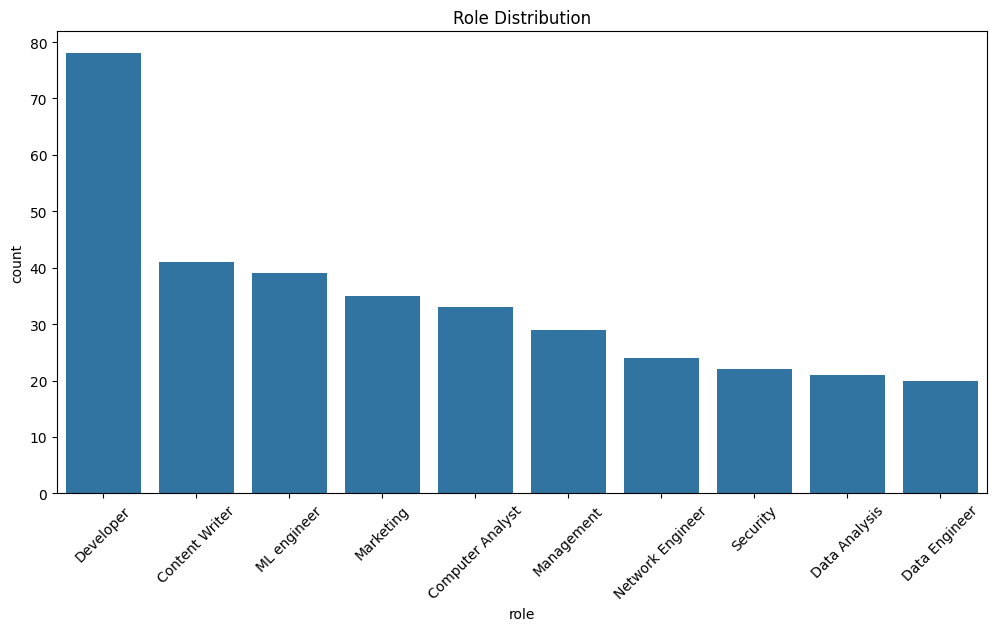

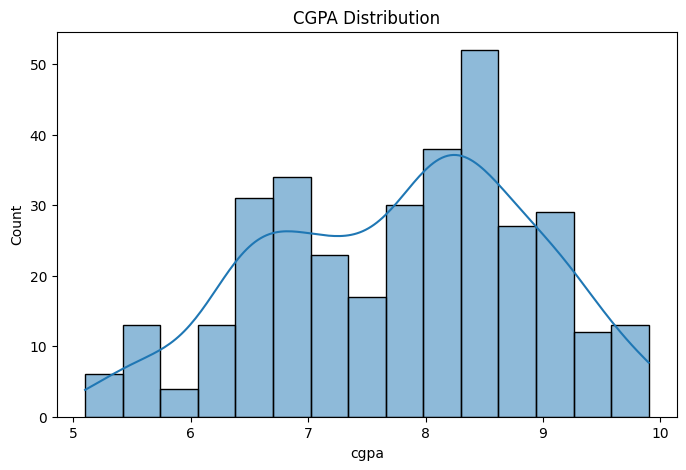

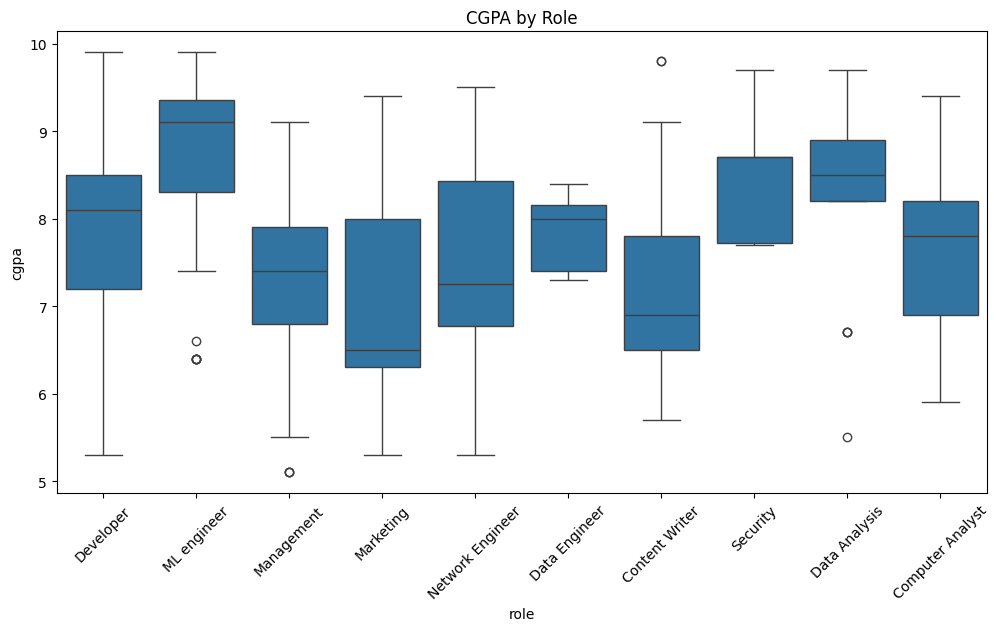

Coding Skill vs Role:
coding            no  yes
role                     
Computer Analyst   2   31
Content Writer    35    6
Data Analysis      1   20
Data Engineer     17    3
Developer          4   74
ML engineer        2   37
Management        28    1
Marketing         25   10
Network Engineer  10   14
Security           0   22



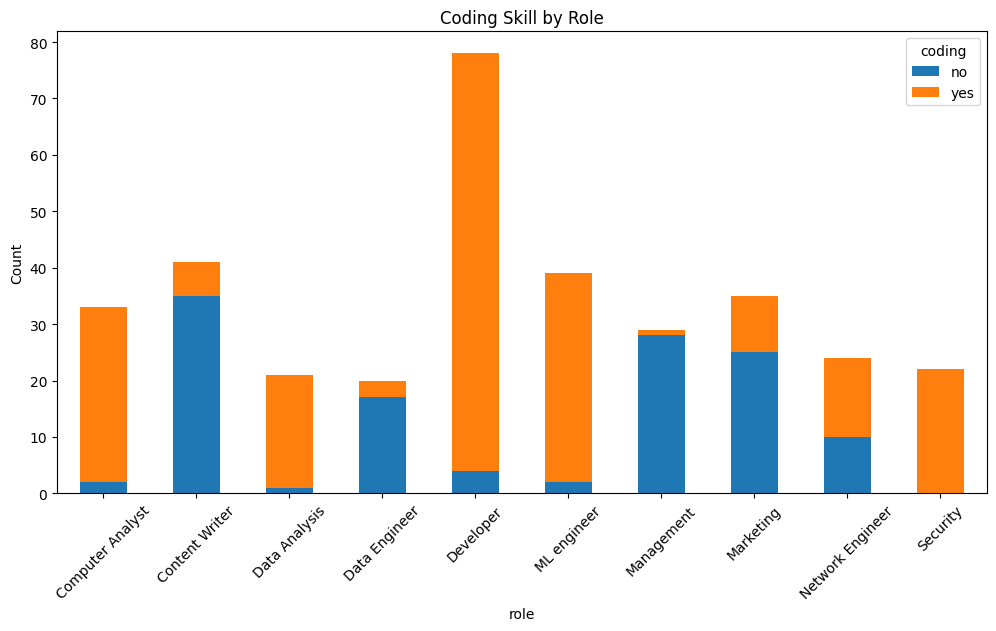

ML Expertise vs Role:
ml_expert         no  yes
role                     
Computer Analyst  31    2
Content Writer    39    2
Data Analysis      6   15
Data Engineer     20    0
Developer         70    8
ML engineer        4   35
Management        29    0
Marketing         35    0
Network Engineer  18    6
Security          22    0



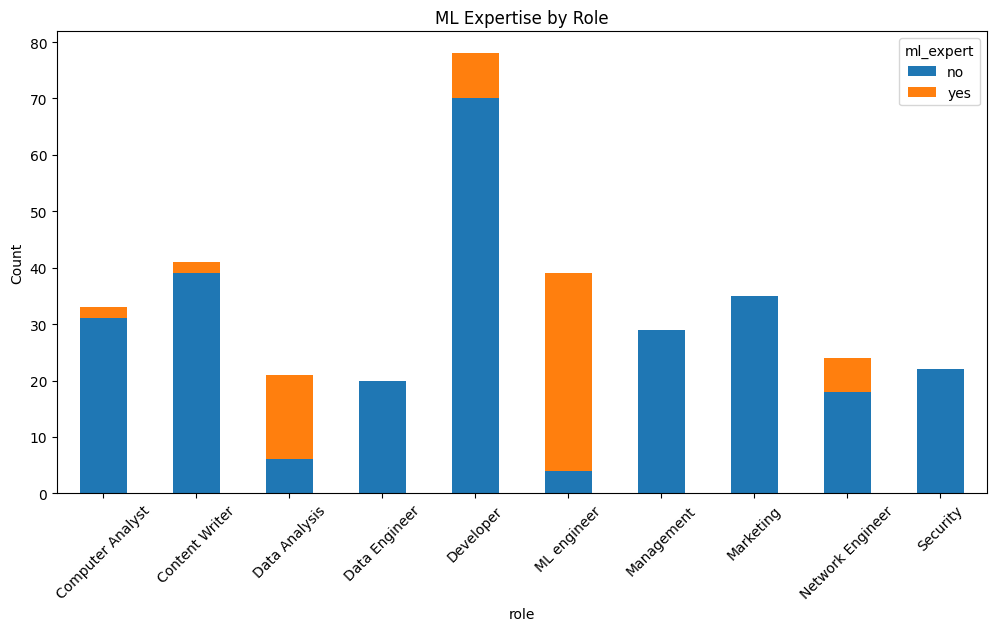

In [16]:
# role distribution visualization

plt.figure(figsize=(12,6))
sns.countplot(data=cleaned_data, x="role", order=cleaned_data["role"].value_counts().index)

plt.title("Role Distribution")
plt.xticks(rotation=45)
plt.show()


# cgpa distribution

plt.figure(figsize=(8,5))
sns.histplot(cleaned_data["cgpa"], bins=15, kde=True)

plt.title("CGPA Distribution")
plt.show()


# cgpa by role

plt.figure(figsize=(12,6))
sns.boxplot(data=cleaned_data, x="role", y="cgpa")

plt.title("CGPA by Role")
plt.xticks(rotation=45)
plt.show()


# relationship between coding skill and role

coding_vs_role = pd.crosstab(cleaned_data["role"], cleaned_data["coding"])

print("Coding Skill vs Role:")
print(coding_vs_role)
print()

coding_vs_role.plot(kind="bar", stacked=True, figsize=(12,6))

plt.title("Coding Skill by Role")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()


# relationship between ML expertise and role

ml_vs_role = pd.crosstab(cleaned_data["role"], cleaned_data["ml_expert"])

print("ML Expertise vs Role:")
print(ml_vs_role)
print()

ml_vs_role.plot(kind="bar", stacked=True, figsize=(12,6))

plt.title("ML Expertise by Role")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# 4. Preprocessing

In [24]:
# separating features and target

X = cleaned_data.drop("role", axis=1)
y = cleaned_data["role"] # want to predict potential role/career given the other features

print("Original feature shape:", X.shape)


# one-hot encoding categorical variables

X_encoded = pd.get_dummies(X, drop_first=True)
# drop_first = true to avoid mutlicollinearity

print("Encoded feature shape:", X_encoded.shape)
print()

print("First couple of encoded columns:")
print(X_encoded.columns[:20])


# scaling cgpa manually

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler() # the cgpa is roughly normal-looking, so this is a good choice to use

X_encoded["cgpa"] = scaler.fit_transform(X_encoded[["cgpa"]])

print()
print("Scaled CGPA summary:")
print(X_encoded["cgpa"].describe())


# train-test split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,   # 80-20 split for better training; cross-val probs will be used later
    random_state=42,
    stratify=y # to preserve proportions
)

print()
print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

print()
print("Training role distribution:")
print(y_train.value_counts())

print()
print("Testing role distribution:")
print(y_test.value_counts())

Original feature shape: (342, 19)
Encoded feature shape: (342, 20)

First couple of encoded columns:
Index(['cgpa', 'webdev_yes', 'data_analysis_yes', 'reading_writing_medium',
       'reading_writing_poor', 'tech_person_yes', 'non_tech_society_yes',
       'coding_yes', 'mobile_apps_yes', 'communication_yes',
       'security_specialization_yes', 'large_databases_yes',
       'stats_ds_knowledge_yes', 'english_yes', 'event_management_yes',
       'technical_blogs_yes', 'marketing_interest_yes', 'ml_expert_yes',
       'connections_yes', 'live_project_yes'],
      dtype='object')

Scaled CGPA summary:
count    3.420000e+02
mean    -2.545073e-16
std      1.001465e+00
min     -2.370486e+00
25%     -7.740838e-01
50%      1.571507e-01
75%      7.336291e-01
max      1.886586e+00
Name: cgpa, dtype: float64

Training shape: (273, 20)
Testing shape: (69, 20)

Training role distribution:
role
Developer           62
Content Writer      33
ML engineer         31
Marketing           28
Computer An